# Análisis EDA para el conjunto de datos relacionado a la calidad del vino blanco
##### Los datos fueron extraídos desde la siguiente url:
- **https://archive.ics.uci.edu/ml/datasets/Wine+Quality**

In [1]:
import os
import sys

carpeta_actual = os.getcwd()
ruta_raiz = os.path.dirname(carpeta_actual)
print(ruta_raiz)
# Añade la raíz al buscador de Python si no está ahí
if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

# Ahora ya puedes importar tus funciones
from utilidades.mis_funciones import *

c:\Users\mbang\Desktop\GitMikis\Proyecto2


In [ ]:
# Cargar el archivo
ruta_archivo = f"{ruta_raiz}/datasets/winequality-white.csv"
df2 = cargar_archivo_drive(ruta_archivo,";")
analisis_inicial(df2)

Tamaño: (4898, 12)

Primeras 5 filas del DataFrame:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         0.32             8.5      0.058   
4            7.2              0.23         0.32             8.5      0.058   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 45.0                 170.0   1.0010  3.00       0.45   
1                 14.0                 132.0   0.9940  3.30       0.49   
2                 30.0                  97.0   0.9951  3.26       0.44   
3                 47.0                 186.0   0.9956  3.19       0.40   
4                 47.0                 186.0   0.9956  3.19       0.40   

   alcohol  quality  
0      8.8  

In [8]:
# Haré una copia por si las moscas
df2_clean = df2.copy()

### Limpiando Duplicados

Como el analisis_inicial me mostró hartos duplicados, lo más conveniente es sacarlos para tener un dataset más limpio y representativo. Así evito sesgos en el análisis.

In [9]:
print(f"Filas antes de eliminar duplicados: {df2_clean.shape[0]}")
df2_clean.drop_duplicates(inplace=True)
print(f"Filas después de eliminar duplicados: {df2_clean.shape[0]}")

display(df2_clean.head())

Filas antes de eliminar duplicados: 4898
Filas después de eliminar duplicados: 3961


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


### Voy a observar qué tan frecuentes son los diferentes niveles de calidad en el dataset. Es bueno para ver si hay un desbalance o si se concentra en ciertas calidades.

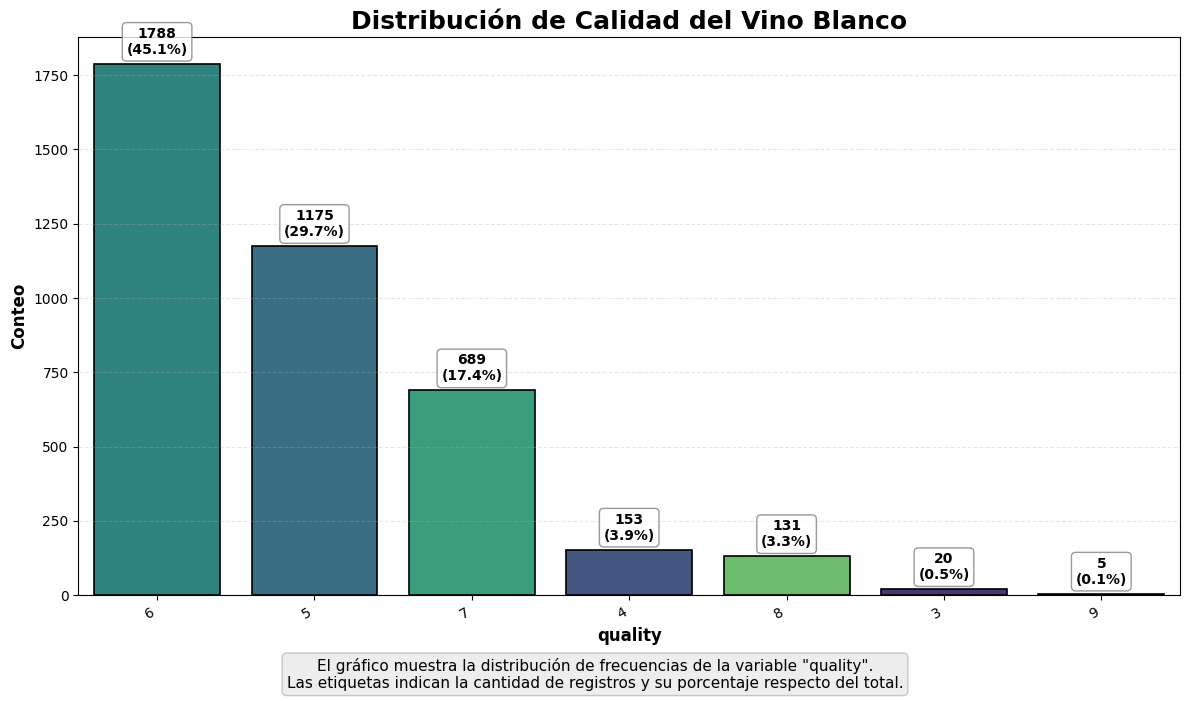

In [10]:
titulodf2 = 'Distribución de Calidad del Vino Blanco'
et_x_df2 = 'Calidad del Vino (0-10)'
et_y_df2 = 'Conteo'

grafico_conteo(df2_clean,'quality',titulodf2,y_label=et_y_df2,x_label=et_x_df2)

### Correlación entre Propiedades Químicas y Calidad

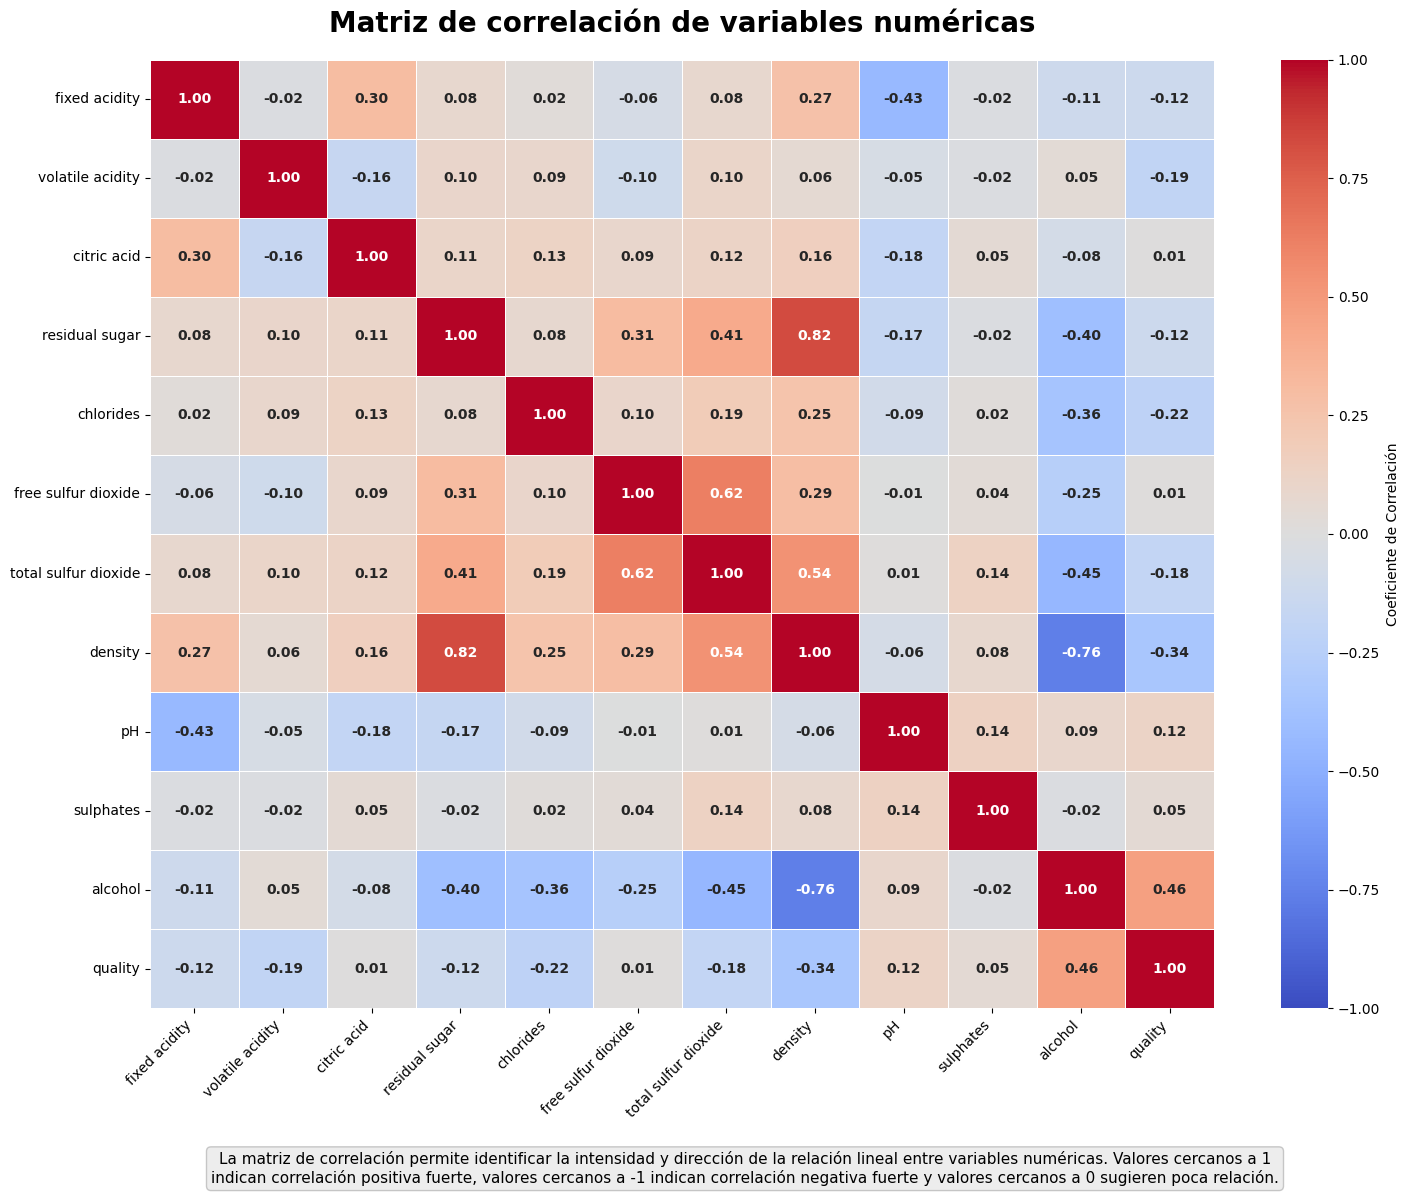

In [11]:
# Voy a conseguir las variables numéricas
col_num_df2 = df2_clean.select_dtypes(include=[np.number]).columns
# Ahora llamo a mi funcion de correlación
matriz_corr(df2_clean, col_num_df2)

### Ya que la matriz de correlación me dio una idea general, ahora voy a ver más en detalle la distribución de cada una de las variables numéricas. Esto me ayudará a entender mejor cómo se comportan los datos de las propiedades del vino y su calidad.

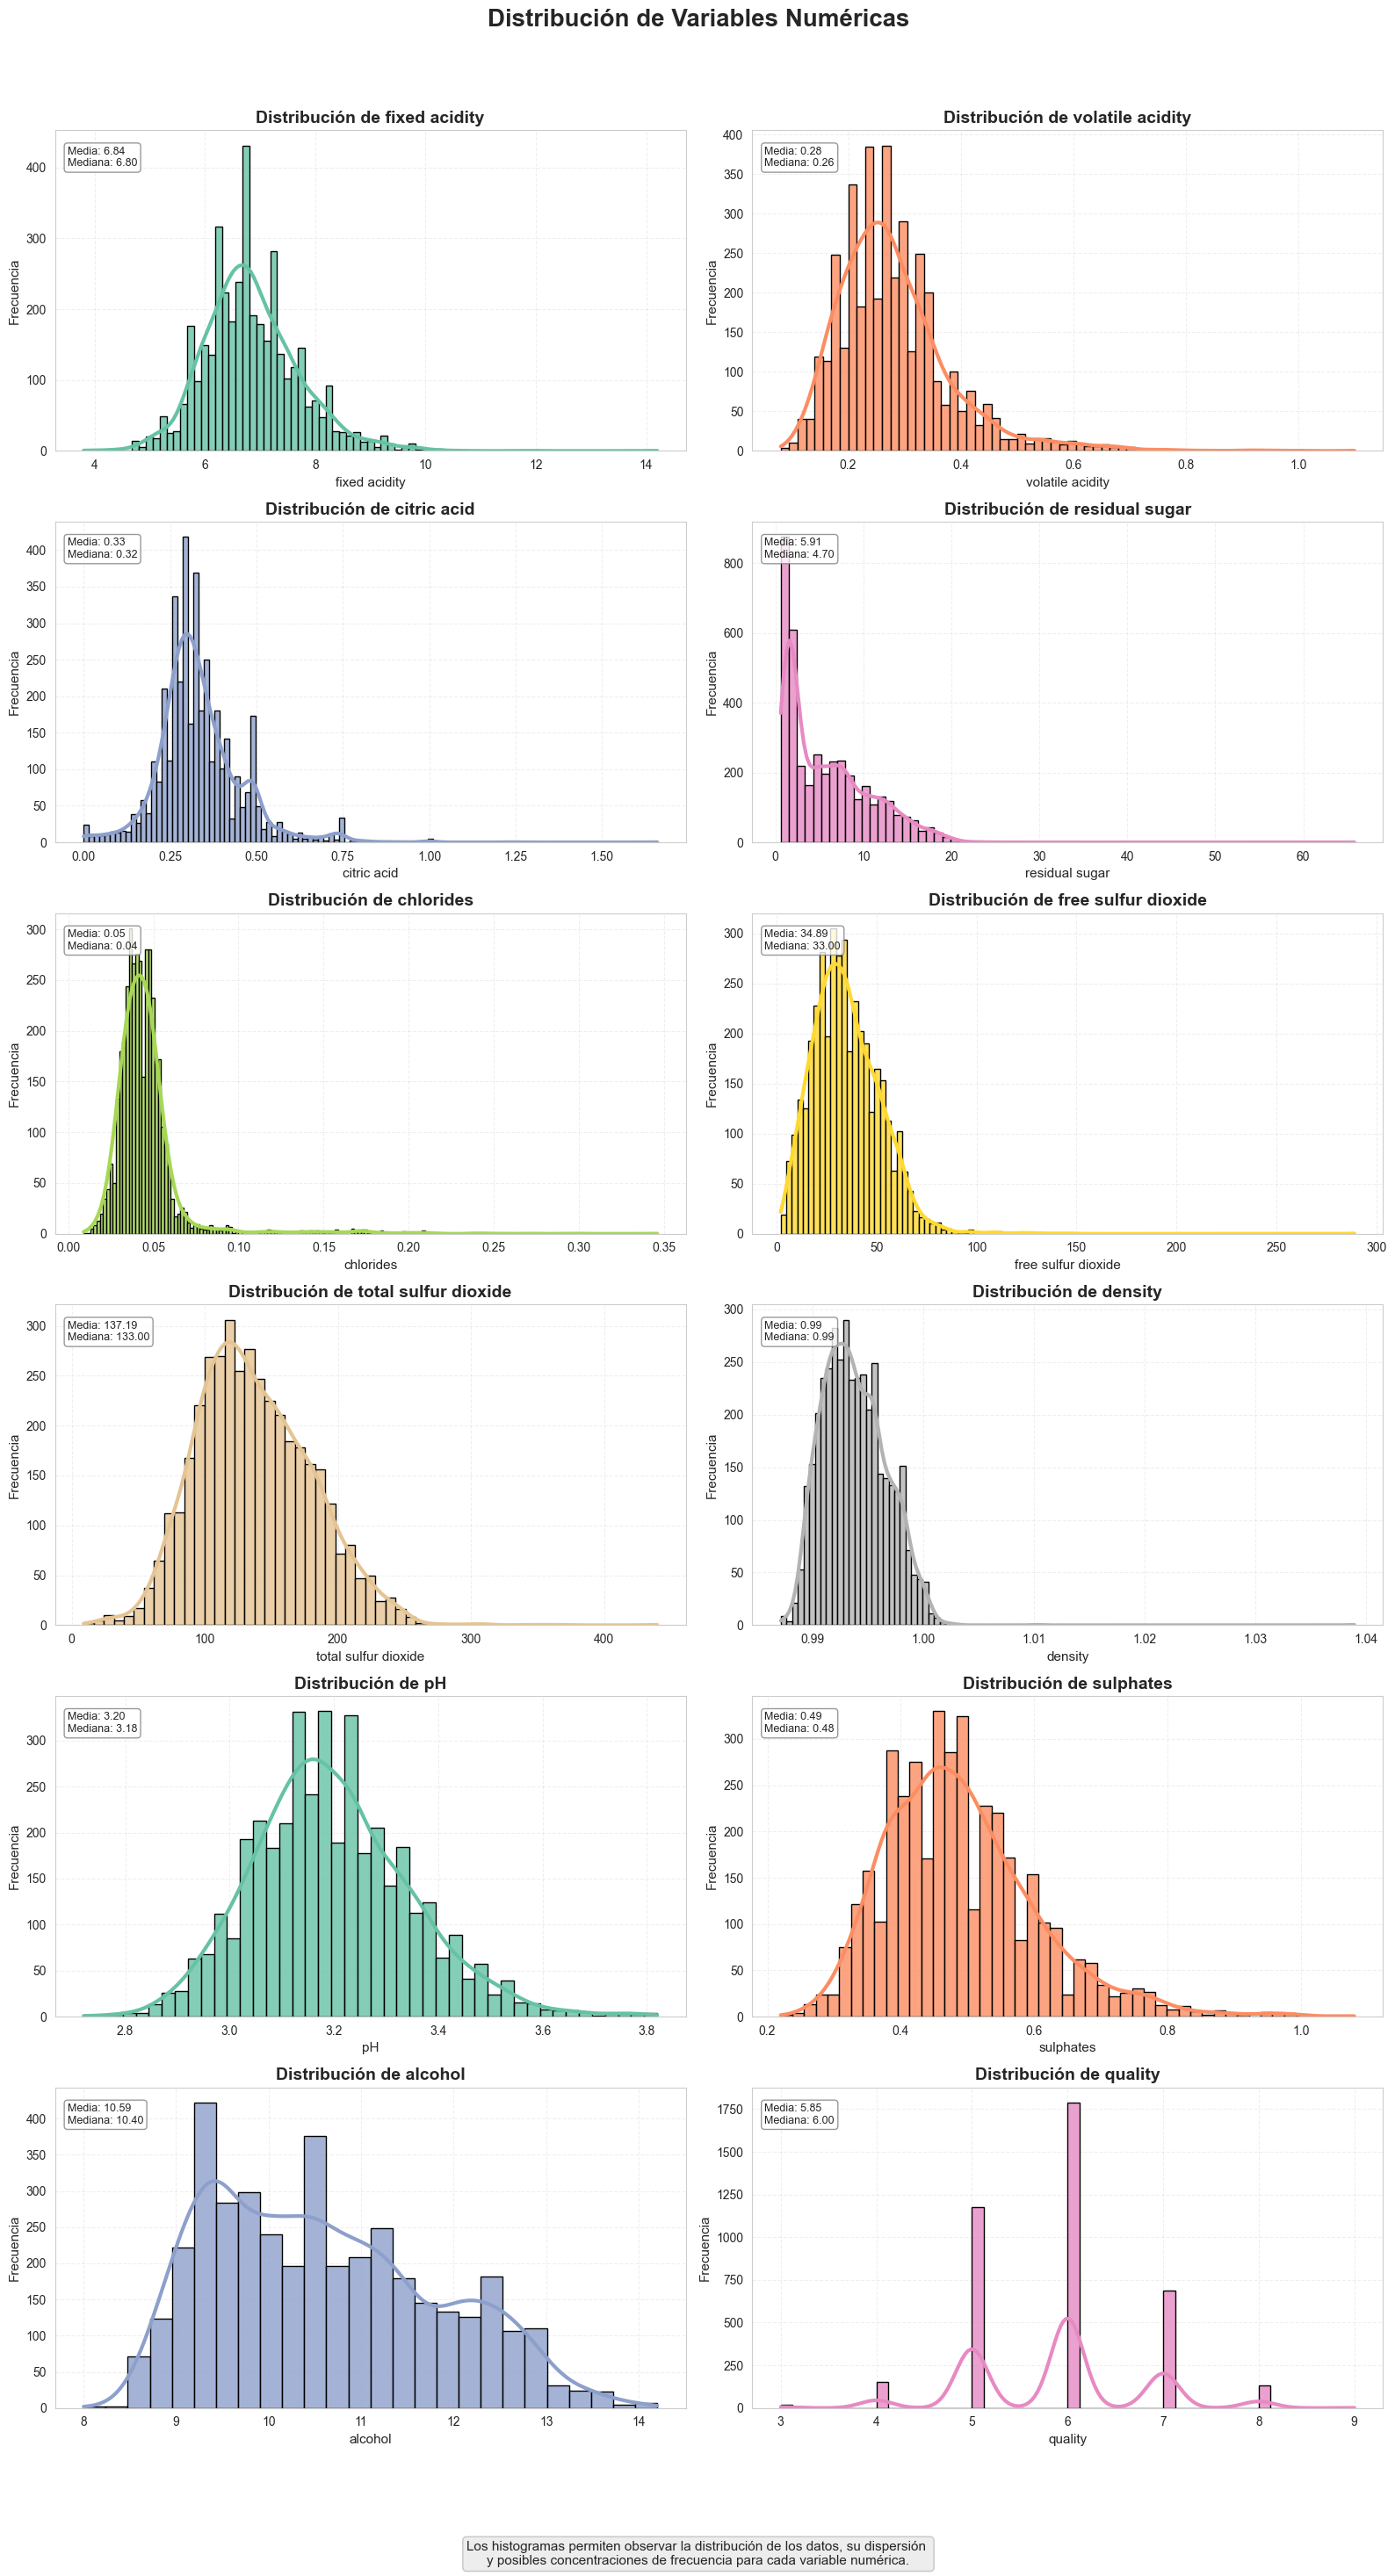

In [12]:
graficar_histogramas(df2_clean)

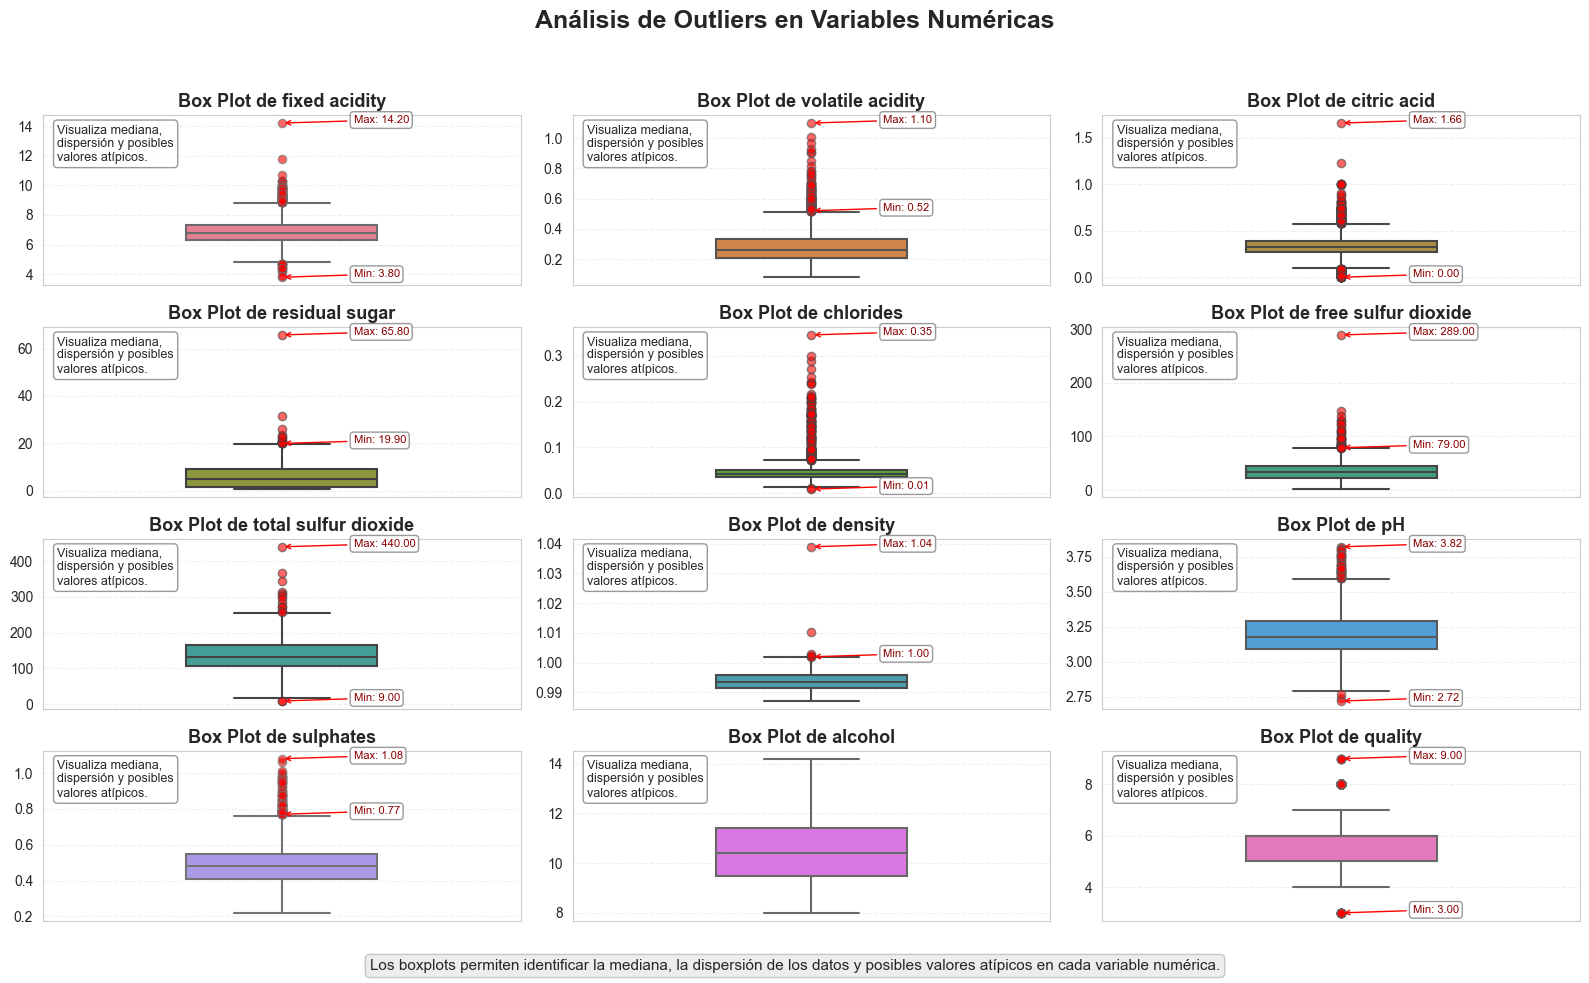

In [13]:
# Identificar columnas numéricas para el análisis de outliers
col_num_df2 = df2_clean.select_dtypes(include=[np.number]).columns.tolist()

boxplots(df2_clean, col_num_df2)

### Resumen del EDA para df2 (Calidad del Vino Blanco)

Después de la limpieza de duplicados y de ver los gráficos, puedo sacar estas conclusiones:

#### Observaciones generales:

* Partí con 4898 registros y 12 columnas. Después de eliminar los duplicados, me quedé con 3961 registros. Esto es importante para tener datos únicos.
* No se encontraron valores nulos en ninguna columna, lo que me ahorra una pega importante.
* Eliminé 937 filas duplicadas. Esto es clave para que el análisis sea más preciso y representativo.

* Se observó que la quality del vino se concentra en valores intermedios (5, 6 y 7), con menos vinos de muy baja (3, 4) o muy alta (8, 9) calidad. Esto es una distribución que tiende a ser normal pero con un sesgo hacia la calidad media-alta. No hay vinos de calidad 0, 1, 2 ni 10 en este dataset.
### La matriz de correlación mostró que algunas variables tienen una relación más fuerte con la calidad que otras. Por ejemplo:
* **alcohol** Tiene una correlación positiva moderada, lo que sugiere que vinos con más alcohol tienden a tener mejor calidad.
* **density**: Muestra una correlación negativa, indicando que a menor densidad, la calidad tiende a ser mejor.
* **free sulfur dioxide y total sulfur dioxide:** También tienen correlaciones, pero su relación con la calidad es más compleja.
* **volatile acidity**, **citric acid** y **chlorides** también tienen cierta relación, pero con coeficientes menores.

#### Outliers:

* Los boxplots me confirmaron que hay outliers en casi todas las variables numéricas. Esto es esperable en datos de este tipo, ya que las propiedades químicas pueden variar bastante.
* La presencia de outliers no siempre significa un error. Pueden ser mediciones legítimas de vinos con características químicas excepcionales. Sin embargo, su presencia puede afectar modelos que son sensibles a valores extremos.
* Para este dataset, el tratamiento de los outliers dependerá del problema. Si busco un modelo de regresión para predecir la calidad, podría considerar transformaciones o métodos para mitigar su impacto. Si estoy identificando vinos atípicos por sus propiedades, los outliers son precisamente el objetivo.

### El problema principal que se viene a la mente es una tarea de clasificación o regresión para predecir la quality del vino basándose en sus propiedades químicas. Podría tratar la calidad como una variable continua (regresión) o como categorías (clasificación). Se podría crear nuevas características, como razones entre diferentes propiedades químicas, para ver si capturan mejor la relación con la calidad. Investigar más a fondo los vinos que son outliers en ciertas propiedades para entender si hay patrones o explicaciones detrás de esos valores extremos.